In [43]:
import numpy as np
import pandas as pd
from faker import Faker
import matplotlib.pyplot as plt

In [44]:
fake = Faker()
Faker.seed(42)

data = {
    "cust_id" : [fake.uuid4() for _ in range(10)],
    "order_id" : fake.random_elements(elements = range(1,11), length = 10, unique = True),
    "order_date" : [fake.date_between(start_date="-1y", end_date="today") for _ in range(10)],
    "order_amount" : fake.random_elements(elements = range(500,1000), length = 10, unique = True),
}
df = pd.DataFrame(data)
df

,cust_id,order_id,order_date,order_amount
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,3,2025-06-20,774
1,23b8c1e9-3924-46de-beb1-3b9046685257,7,2025-09-30,563
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,6,2026-04-08,998
3,972a8469-1641-4f82-8b9d-2434e465e150,10,2025-09-24,972
4,17fc695a-07a0-4a6e-8822-e8f36c031199,2,2026-01-03,693
5,9a1de644-815e-46d1-bb8f-aa1837f8a88b,8,2025-08-24,540
6,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,9,2026-03-23,782
7,6b65a6a4-8b81-48f6-b38a-088ca65ed389,1,2025-05-30,650
8,47378190-96da-4dac-b2ff-5d2a386ecbe0,4,2026-02-21,924
9,c241330b-01a9-471f-9e8a-774bcf36d58b,5,2025-11-08,821


In [45]:
date_time = pd.to_datetime(df["order_date"])
print(f"Order date converted to date time :- \n{date_time}")

Order date converted to date time :- 
0   2025-06-20
1   2025-09-30
2   2026-04-08
3   2025-09-24
4   2026-01-03
5   2025-08-24
6   2026-03-23
7   2025-05-30
8   2026-02-21
9   2025-11-08
Name: order_date, dtype: datetime64[s]


In [46]:
df["order_date"] = pd.to_datetime(df["order_date"])
df

,cust_id,order_id,order_date,order_amount
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,3,2025-06-20,774
1,23b8c1e9-3924-46de-beb1-3b9046685257,7,2025-09-30,563
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,6,2026-04-08,998
3,972a8469-1641-4f82-8b9d-2434e465e150,10,2025-09-24,972
4,17fc695a-07a0-4a6e-8822-e8f36c031199,2,2026-01-03,693
5,9a1de644-815e-46d1-bb8f-aa1837f8a88b,8,2025-08-24,540
6,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,9,2026-03-23,782
7,6b65a6a4-8b81-48f6-b38a-088ca65ed389,1,2025-05-30,650
8,47378190-96da-4dac-b2ff-5d2a386ecbe0,4,2026-02-21,924
9,c241330b-01a9-471f-9e8a-774bcf36d58b,5,2025-11-08,821


In [49]:
df["month"] = df["order_date"].dt.to_period("M")
df

,cust_id,order_id,order_date,order_amount,month
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,3,2025-06-20,774,2025-06
1,23b8c1e9-3924-46de-beb1-3b9046685257,7,2025-09-30,563,2025-09
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,6,2026-04-08,998,2026-04
3,972a8469-1641-4f82-8b9d-2434e465e150,10,2025-09-24,972,2025-09
4,17fc695a-07a0-4a6e-8822-e8f36c031199,2,2026-01-03,693,2026-01
5,9a1de644-815e-46d1-bb8f-aa1837f8a88b,8,2025-08-24,540,2025-08
6,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,9,2026-03-23,782,2026-03
7,6b65a6a4-8b81-48f6-b38a-088ca65ed389,1,2025-05-30,650,2025-05
8,47378190-96da-4dac-b2ff-5d2a386ecbe0,4,2026-02-21,924,2026-02
9,c241330b-01a9-471f-9e8a-774bcf36d58b,5,2025-11-08,821,2025-11


Monthly Revenue:- 
     month  revenue
0  2025-05      650
1  2025-06      774
2  2025-08      540
3  2025-09     1535
4  2025-11      821
5  2026-01      693
6  2026-02      924
7  2026-03      782
8  2026-04      998


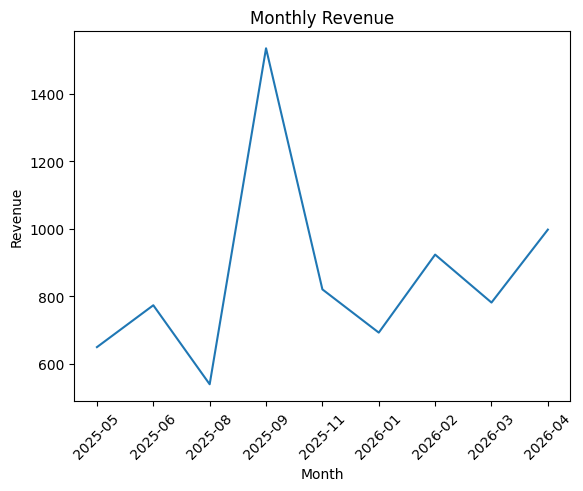

In [67]:
monthly_revenue = df.groupby("month")["order_amount"].sum().reset_index()
monthly_revenue.columns = ["month", "revenue"]
monthly_revenue["month"] = monthly_revenue["month"].astype(str)
print(f"Monthly Revenue:- \n{monthly_revenue}")
plt.plot(monthly_revenue["month"], monthly_revenue["revenue"])
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.show()

In [70]:
monthly_customer = df.groupby("month")["cust_id"].nunique()
print(f"Monthly Customers numbers:- \n{monthly_customer}")
top_match = monthly_customer.idxmax()
print(f"Top buy:- \n{top_match}")

Monthly Customers numbers:- 
month
2025-05    1
2025-06    1
2025-08    1
2025-09    2
2025-11    1
2026-01    1
2026-02    1
2026-03    1
2026-04    1
Freq: M, Name: cust_id, dtype: int64
Top buy:- 
2025-09
